In [1]:
import numpy as np
from statsmodels.tsa.arima_process import ArmaProcess

# 3.1.1

1

In [2]:
arima_process = ArmaProcess(ar = [1, -1, 0.25], ma=[1, 0.8, 0])

In [3]:
arima_process.isstationary

True

In [4]:
arima_process.isinvertible

True

4

In [5]:
arima_process = ArmaProcess(ar = [1, 1.9, -0.2], ma=[1, -1.6, -0.36])

In [6]:
arima_process.isstationary

False

In [7]:
arima_process.isinvertible

False

# 3.2.1

In [8]:
import pandas as pd

# импорт из библиотеки statsmodels
from sktime.forecasting.arima import StatsModelsARIMA as ARIMA
# импорт из пакета pmdarima
from sktime.forecasting.arima import AutoARIMA

# Базовые трансформеры
from sktime.transformations.series.boxcox import LogTransformer, BoxCoxTransformer
from sktime.transformations.series.difference import Differencer

from sktime.utils.plotting import plot_series
# временной горизонт для прогнозирования
from sktime.forecasting.base import ForecastingHorizon

import pandas_datareader.data as web

# настройки визуализации
import matplotlib.pyplot as plt

# Не показывать Warnings
import warnings
warnings.simplefilter(action='ignore', category=Warning)
# Не показывать ValueWarning, ConvergenceWarning из statsmodels
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning
warnings.simplefilter('ignore', category=ValueWarning)
warnings.simplefilter('ignore', category=ConvergenceWarning)

In [9]:
y = web.DataReader(name='GDP', data_source='fred', start='1995-01')
y.index = y.index.to_period(freq='Q')
y

,GDP
DATE,
1995Q1,7522.289
1995Q2,7580.997
1995Q3,7683.125
1995Q4,7772.586
1996Q1,7868.468
...,...
2024Q4,29825.182
2025Q1,30042.113
2025Q2,30485.729


In [10]:
#  создадим pipeline из преобразования и модели для прогнозирован
pipe = LogTransformer() * ARIMA(order=(1,0,1), trend='ct')

fh = ForecastingHorizon(np.arange(1,11), freq ='Q')

y_pred = pipe.fit_predict(y=y, fh=fh)
y_pred

,GDP
2026Q1,31801.952472
2026Q2,32122.077880
2026Q3,32447.039972
2026Q4,32776.853968
2027Q1,33111.536661
2027Q2,33451.106379
2027Q3,33795.582945
2027Q4,34144.987643
2028Q1,34499.343185
2028Q2,34858.673679


(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='GDP'>)

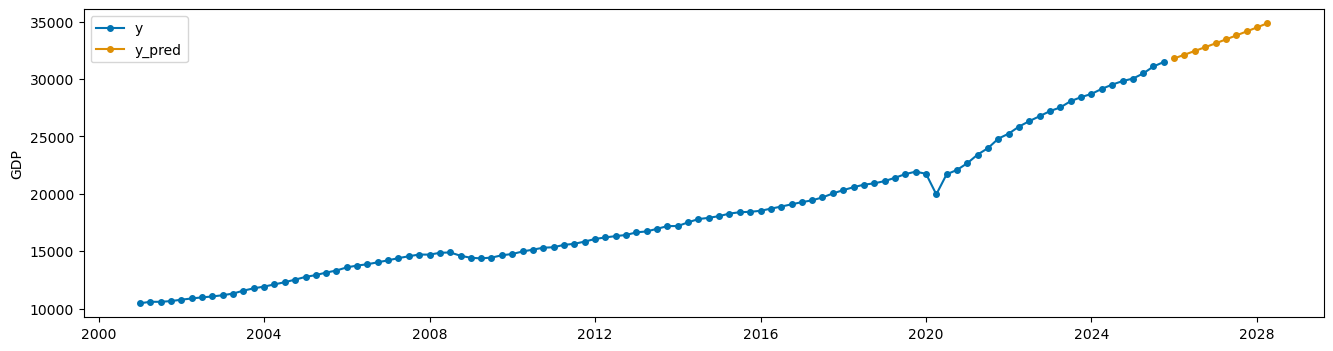

In [11]:
plot_series(y.tail(100), y_pred, labels=['y', 'y_pred'])

In [12]:
#  создадим pipeline из преобразования и модели для прогнозирован
pipe_bc = BoxCoxTransformer() * ARIMA(order=(1,0,1), trend='ct')
y_pred_bc = pipe.fit_predict(y=y, fh=fh)
y_pred_bc

,GDP
2026Q1,31801.952472
2026Q2,32122.077880
2026Q3,32447.039972
2026Q4,32776.853968
2027Q1,33111.536661
2027Q2,33451.106379
2027Q3,33795.582945
2027Q4,34144.987643
2028Q1,34499.343185
2028Q2,34858.673679


(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='GDP'>)

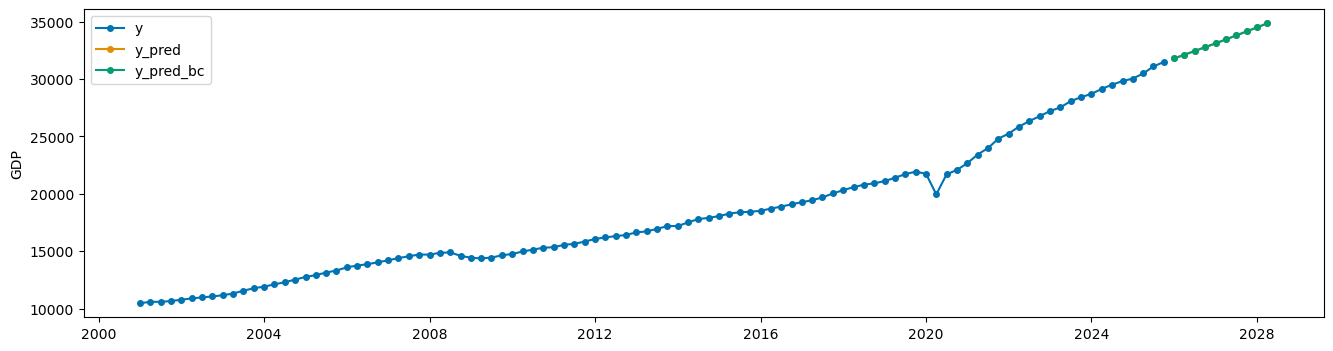

In [13]:
plot_series(y.tail(100), y_pred, y_pred_bc, labels=['y', 'y_pred', 'y_pred_bc'])

In [14]:
#  создадим pipeline из преобразования и модели для прогнозирован
pipe2 = LogTransformer() * ARIMA(order=(1,1,0), trend='t')
y_pred2 = pipe.fit_predict(y=y, fh=fh)
y_pred2

,GDP
2026Q1,31801.952472
2026Q2,32122.077880
2026Q3,32447.039972
2026Q4,32776.853968
2027Q1,33111.536661
2027Q2,33451.106379
2027Q3,33795.582945
2027Q4,34144.987643
2028Q1,34499.343185
2028Q2,34858.673679


In [15]:
#  создадим pipeline из преобразования и модели для прогнозирован
pipe_bc2 = BoxCoxTransformer() * ARIMA(order=(1,1,0), trend='t')
y_pred_bc2 = pipe.fit_predict(y=y, fh=fh)
y_pred_bc2

,GDP
2026Q1,31801.952472
2026Q2,32122.077880
2026Q3,32447.039972
2026Q4,32776.853968
2027Q1,33111.536661
2027Q2,33451.106379
2027Q3,33795.582945
2027Q4,34144.987643
2028Q1,34499.343185
2028Q2,34858.673679


(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='GDP'>)

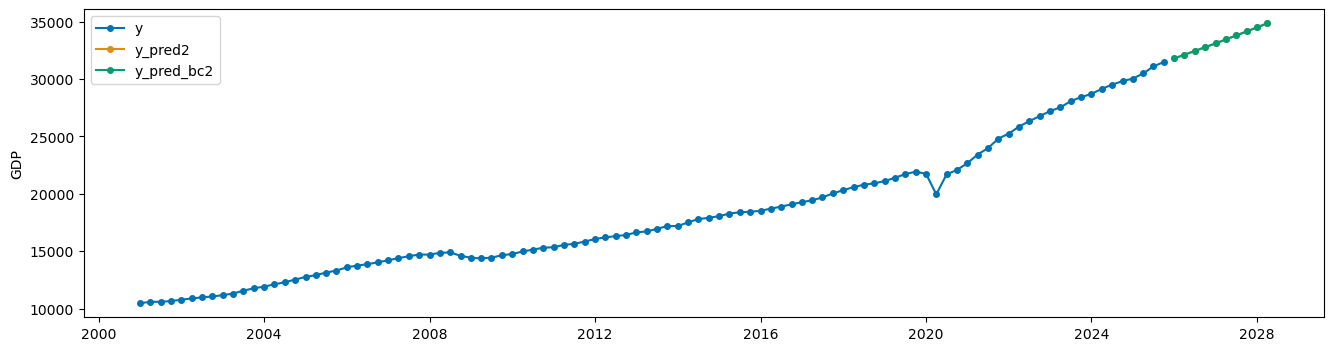

In [23]:
plot_series(y.tail(100), y_pred2, y_pred_bc2, labels=['y', 'y_pred2', 'y_pred_bc2'])

In [17]:
#  создадим pipeline из преобразования и модели для прогнозирован
pipe3 = LogTransformer() * ARIMA(order=(1,1,1), trend='n')
y_pred3 = pipe.fit_predict(y=y, fh=fh)
y_pred3

,GDP
2026Q1,31801.952472
2026Q2,32122.077880
2026Q3,32447.039972
2026Q4,32776.853968
2027Q1,33111.536661
2027Q2,33451.106379
2027Q3,33795.582945
2027Q4,34144.987643
2028Q1,34499.343185
2028Q2,34858.673679


In [18]:
#  создадим pipeline из преобразования и модели для прогнозирован
pipe_bc3 = BoxCoxTransformer() * ARIMA(order=(1,1,1), trend='n')
y_pred_bc3 = pipe.fit_predict(y=y, fh=fh)
y_pred_bc3

,GDP
2026Q1,31801.952472
2026Q2,32122.077880
2026Q3,32447.039972
2026Q4,32776.853968
2027Q1,33111.536661
2027Q2,33451.106379
2027Q3,33795.582945
2027Q4,34144.987643
2028Q1,34499.343185
2028Q2,34858.673679


(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='GDP'>)

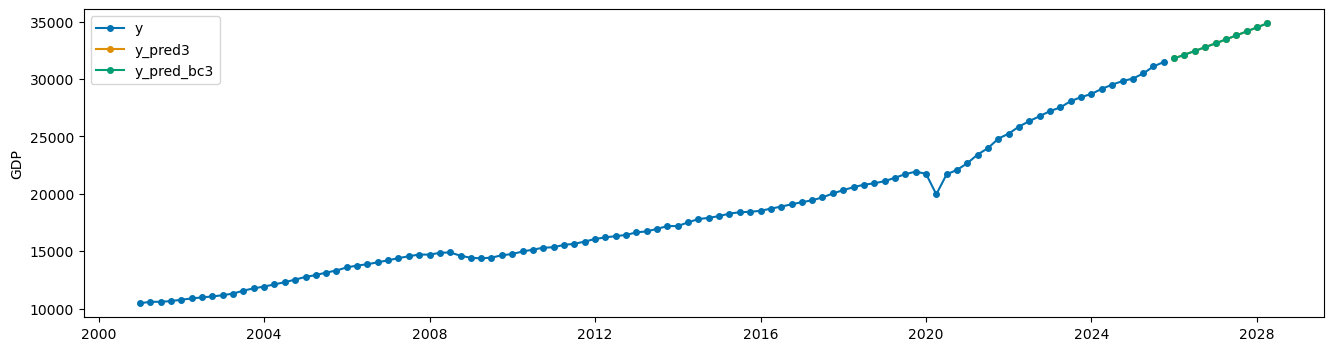

In [24]:
plot_series(y.tail(100), y_pred3, y_pred_bc3, labels=['y', 'y_pred3', 'y_pred_bc3'])

In [20]:
#  создадим pipeline из преобразования и модели для прогнозирован
pipe4 = LogTransformer() * ARIMA(order=(1,2,0), trend='n')
y_pred4 = pipe.fit_predict(y=y, fh=fh)
y_pred4

,GDP
2026Q1,31801.952472
2026Q2,32122.077880
2026Q3,32447.039972
2026Q4,32776.853968
2027Q1,33111.536661
2027Q2,33451.106379
2027Q3,33795.582945
2027Q4,34144.987643
2028Q1,34499.343185
2028Q2,34858.673679


In [21]:
#  создадим pipeline из преобразования и модели для прогнозирован
pipe_bc4 = BoxCoxTransformer() * ARIMA(order=(1,2,0), trend='n')
y_pred_bc4 = pipe.fit_predict(y=y, fh=fh)
y_pred_bc4

,GDP
2026Q1,31801.952472
2026Q2,32122.077880
2026Q3,32447.039972
2026Q4,32776.853968
2027Q1,33111.536661
2027Q2,33451.106379
2027Q3,33795.582945
2027Q4,34144.987643
2028Q1,34499.343185
2028Q2,34858.673679


(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='GDP'>)

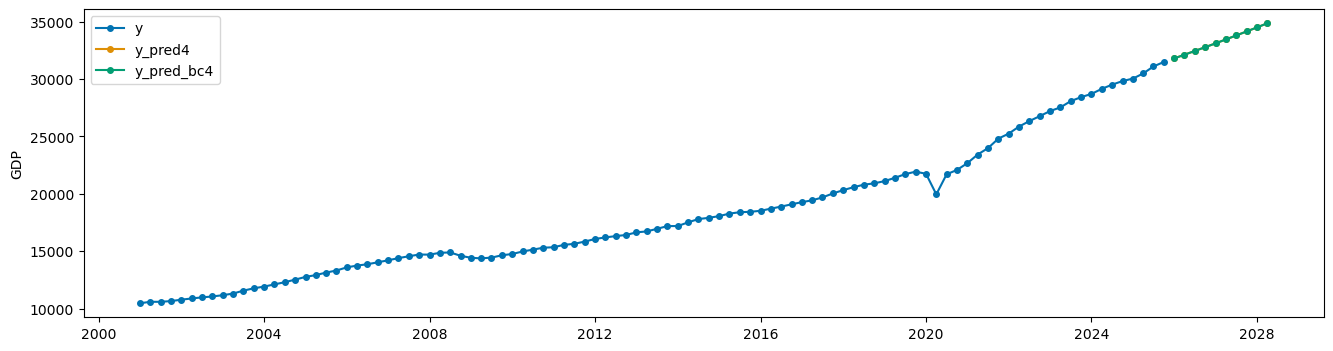

In [25]:
plot_series(y.tail(100), y_pred4, y_pred_bc4, labels=['y', 'y_pred4', 'y_pred_bc4'])

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='GDP'>)

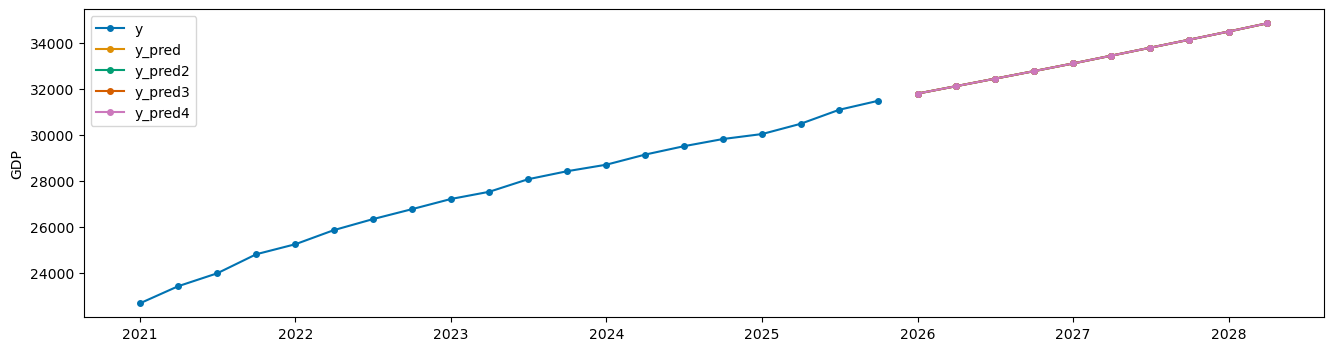

In [27]:
plot_series(y.tail(20), y_pred, y_pred2, y_pred3, y_pred4, labels=['y', 'y_pred', 'y_pred2', 'y_pred3', 'y_pred4'])

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='GDP'>)

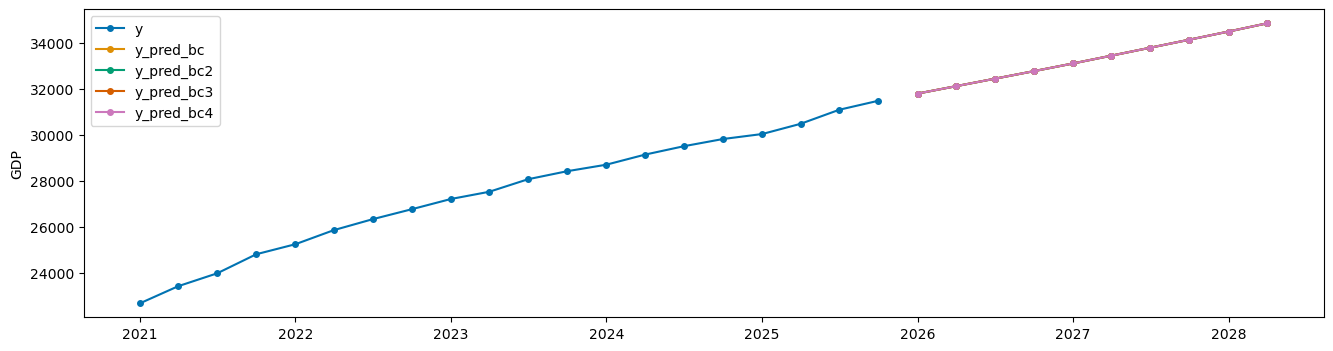

In [28]:
plot_series(y.tail(20), y_pred_bc, y_pred_bc2, y_pred_bc3, y_pred_bc4, labels=['y', 'y_pred_bc', 'y_pred_bc2', 'y_pred_bc3', 'y_pred_bc4'])